# Fitting the Fisher–KPP lesion-growth model to one pea stipule image sequence (LesionKPP)

**Paper:** Leclerc M, Jumel S, Hamelin FM, Treilhaud R, Parisey N, Mammeri Y (2023)
*Imaging with spatio-temporal modelling to characterize the dynamics of plant-pathogen lesions.*
PLoS Comput Biol 19(11): e1011627. https://doi.org/10.1371/journal.pcbi.1011627 (Version 2, 2023-11-20)

**Author code:** LesionKPP, Youcef Mammeri (GPL-3.0), pinned commit
`fa1cb6f4d2de71c6e19eba34d3a23e7854f8ba1e` — https://plmlab.math.cnrs.fr/ymammeri/lesionkpp

**Scope — partial demonstration (one stipule).** This notebook reproduces the paper's core
parameter-estimation step on the **single example sequence `1_B1_Sol_1` (pea cv. Solara, plant B1,
stipule 1) bundled by the authors with the code**: it fits the Fisher–KPP reaction–diffusion model
to the Weka symptomatic-probability image sequence (days 3–7) by variational data assimilation
(forward KPP solve + adjoint backward solve + gradient updates) and estimates the diffusion
coefficient *D*, the local growth rate *a* and the carrying capacity *K*. Results are compared
with the per-stipule values of the paper's **S6 Appendix** (Table A row 1, Solara: D̂ = 0.451,
â = 0.484, J = 1.76e-02). It is **not** a reproduction of the 32-stipule dataset analysis, the
ANOVA, or the classifier training.

**ADAPTED PYTHON DEMONSTRATION (solver substitution).** The authors' code uses PETSc/petsc4py
purely as a sparse linear solver. **AI-assisted adaptation:** PETSc `Mat`/`KSP` calls are replaced
by `scipy.sparse` matrices + a SuperLU factorization; the discretization, boundary conditions,
growth step, adjoint and gradient formulas are copied verbatim from the author code. The authors
did not provide this Colab implementation; the executed example and listed checks were validated,
but untested behavior is not guaranteed.

**日本語要約:** このノートブックは、エンドウ褐紋病病斑の画像系列(著者公開の Solara 品種スタイ
ユール 1 例)に対して Fisher–KPP 反応拡散モデルを変分データ同化で当てはめ、拡散係数 D と成長率
a を推定します。著者の PETSc ソルバーを SciPy に置き換えた** Adapted Python demonstration**
であり、離散化・最適化の数式は著者コードからの逐次コピーです。結果は論文 S6 付録の表 A 第 1 行
と比較します。全 32 個体の解析・ANOVA・分類器学習は範囲外です。

**Execution status:** validated end-to-end on a fresh Google Colab CPU runtime (see final cells
for measured times). Recommended runtime: **CPU** (no GPU is used anywhere in the author pipeline).


## 1. Runtime selection

This reproduction is CPU-only: the author pipeline is a sparse-matrix PDE solve
(`scipy.sparse.linalg.splu`) on a ~10⁵-node 2-D grid, with no neural network and no CUDA code.
Select **Runtime → Change runtime type → CPU** (the free default) and then **Runtime → Run all**.

Expected end-to-end time on Colab CPU: **about 5–15 minutes**, dominated by the forward/backward
time-stepping (400 implicit solves per pass, ≤ 6 passes) and a few MB of downloads.
**日本語:** GPU は不要です。「ランタイム → ランタイムのタイプを変更 → CPU」を選んでから
「ランタイム → すべてのセルを実行」してください。所要時間は約 5〜15 分です。

In [ ]:
import sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())
print("This reproduction needs CPU only - no GPU/CUDA is used.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
This reproduction needs CPU only - no GPU/CUDA is used.


## 2. Dependencies

The author README lists `petsc/petsc4py, scikit-image, natsort, pyevtk, tqdm`. PETSc requires a
compiled PETSc library that is not practically installable on Colab, so this notebook replaces it
with `scipy.sparse` (see the adaptation notice above). `pyevtk`/`tqdm` outputs (VTK files,
progress bars) are omitted and replaced by in-notebook PNG figures. We install only the small
missing package `natsort`; `numpy`, `scipy`, `scikit-image`, `matplotlib`, `pandas` are preinstalled.
**日本語:** PETSc は Colab に導入できないため SciPy の疎行列ソルバーで置き換えます。追加で必要な
のは `natsort` のみです。

In [ ]:
%pip install -q natsort

import numpy, scipy, skimage, matplotlib, pandas
import natsort
print("numpy", numpy.__version__, "| scipy", scipy.__version__,
      "| scikit-image", skimage.__version__, "| natsort", natsort.__version__)

numpy 2.1.3 | scipy 1.16.3 | scikit-image 0.25.2 | natsort 8.4.0


## 3. Download the pinned author code (provenance)

We fetch the ten code/documentation files of the LesionKPP repository at the pinned commit
`fa1cb6f4d2de71c6e19eba34d3a23e7854f8ba1e` (GPL-3.0, © 2022 Youcef Mammeri) via the GitLab raw
endpoint and verify each file's SHA-256 against the hashes recorded when the same files were
retrieved on the orchestrating host. The functions used below are then ported verbatim from
`steps.py`, `readRegions.py`, `readImages.py` and the driver `LoopOnFolders.py`.
**日本語:** 著者コードを pinned commit から取得し、SHA-256 を照合します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "fa1cb6f4d2de71c6e19eba34d3a23e7854f8ba1e"
RAW = f"https://plmlab.math.cnrs.fr/ymammeri/lesionkpp/-/raw/{COMMIT}"

# path -> sha256 (recorded 2026-10-05 on the host from the same endpoint/commit)
CODE_SHA256 = {
    "README.md": "84328647512ff9522a5d01caf9f7ebadbc7821c7f2d3473af7c4ad216d4890b8",
    "codemeta.json": "ea092d9f47e8bbcfaad48770ab4b6334422c248991d296c58a749df10c4fe97b",
    "code/LoopOnFolders.py": "deed983080330e8d30219a47a5479321deba6d21247c3bbe23e5af048dcf5ba1",
    "code/LoopOnFoldersAdapt.py": "44360691e4dabe2841881f2078faec79751cfccd8c12206e5bfdcff63b672d45",
    "code/Parameters.py": "721360a94ee419bab29a0dfd18f54bb7bf0d825c33a0899c1627842fa457776c",
    "code/forward_petsc.py": "8908608b61da94415751293375fb50b98301ac50e901a718d47c3254c232674b",
    "code/mergeresult.py": "4221e1c768b584e8955fe8d6f04628236f90920b54e6347bce793cc20b52b3b4",
    "code/readFolders.py": "10450aa4289cec69399afee3e15982ee9c32c67ab05ea346fad220c5e6024c3d",
    "code/readImages.py": "c2e50f28a68adabea536eafd06d6bb722f38aea2f414d96a9d2cdd5adb560014",
    "code/readRegions.py": "fe366c6d6489fc70e4c613d8c20919bab5a1b07926f62de913b21af3c444aca3",
    "code/steps.py": "6ca076fa16706f8fd9aa2c5a161285d7f51417f8868bf481e80d9f64f84871ae",
}

SRC_DIR = pathlib.Path("/content/lesionkpp_src")
SRC_DIR.mkdir(parents=True, exist_ok=True)
for rel, want in CODE_SHA256.items():
    dest = SRC_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{RAW}/{rel}", dest)
    got = hashlib.sha256(dest.read_bytes()).hexdigest()
    assert got == want, f"sha256 mismatch for {rel}: {got}"
print(f"OK: {len(CODE_SHA256)} code/doc files match pinned SHA-256 at commit {COMMIT[:12]}...")

OK: 11 code/doc files match pinned SHA-256 at commit fa1cb6f4d2de...


## 4. Download the example image sequence (the minimal input)

The repository ships one complete test sequence `code/images/1_B1_Sol_1` (pea stipule, cv.
Solara, plant B1): `1_Prediction_Weka/` holds the Weka leaf predictions (the computational
domain Ω) and `1_ProbaMaps/` the symptomatic-class probability maps, including the `*_necrose`
maps used by the fitting code. Six acquisition dates `M0..M5` are present; following the author
driver's indexing (`PROBA[s*6+1 .. s*6+5]` with `s = 0`), **M1 is the initial condition (day 3)
and M2..M5 are the observations at T = 1..4**. Each TIFF is verified with its pinned Git blob
SHA-1 and the TIFF magic bytes. All image bytes stay on the Colab VM.
**日本語:** 著者リポジトリ同梱の 1 例画像系列(18 枚の TIFF)をダウンロードし、Git blob SHA-1 と
TIFF シグネチャで検証します。M1 を初期条件、M2〜M5 を観測として使います(著者ドライバの
インデックスに従います)。

In [ ]:
import hashlib

IMG_ROOT = "/content/lesionkpp_images"
# path -> git blob sha1 at the pinned commit (from the GitLab tree API, 2026-10-05)
IMG_BLOBS = {
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M0_1_1.tif": "caf0e85f43dfc06b95f81b8c1255dfb65684f6e1",
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M1_115_1.tif": "3ab89b120e271c939463551c0b5a4361ea02ca2c",
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M2_229_1.tif": "26109386d9432c63635bc2e22f366d68a0d50ca1",
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M3_343_1.tif": "2ec0f3788be6f5e89af2e9426230cd21a43e92a0",
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M4_457_1.tif": "845a131162bb5a6fdd397830687c7bed9f6b178a",
    "code/images/1_B1_Sol_1/1_Prediction_Weka/B1_Sol_M5_571_1.tif": "7635bd3cd90f74a0b10877ffea71aa27ae8daa68",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M0_1_1.tif": "b0044d5159cd1e71e94dc9f9e0f4fb95c19f87e1",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M0_1_1_necrose.tif": "30c780bd1f6801a1687e61b10d171e7b7c868b03",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M1_115_1.tif": "882c8588b39505921e66b3d97e55aaf7253e7c48",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M1_115_1_necrose.tif": "c6636f1ee5c7b6ac9d54af2c071556fbc879d42c",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M2_229_1.tif": "b4357e219b4039663d5e77ab9783355167055b27",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M2_229_1_necrose.tif": "d72d526f855b745e67a9276963baa123ca22b4b4",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M3_343_1.tif": "75acd33b886110189adff5b0994ffc60ddac7d57",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M3_343_1_necrose.tif": "d905bd5e3a3dfcce44627f654a1c94650cbc550d",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M4_457_1.tif": "8ebc77831ef81e13126cdbc1c94400363ceb370a",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M4_457_1_necrose.tif": "4d0d8c8594578ae22f05d2321801f82f69b6b08d",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M5_571_1.tif": "71b37bdf8b8b1a4ec335ee2fa4a065e3fabc6beb",
    "code/images/1_B1_Sol_1/1_ProbaMaps/B1_Sol_M5_571_1_necrose.tif": "1668353c24d79386e26e9f5edfacf394358a3205",
}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for rel, want in IMG_BLOBS.items():
    dest = pathlib.Path(IMG_ROOT) / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{RAW}/{rel}", dest)
    data = dest.read_bytes()
    assert data[:4] in (b"II*\x00", b"MM\x00*"), f"not a TIFF: {rel}"
    assert git_blob_sha1(data) == want, f"blob sha1 mismatch: {rel}"
print(f"OK: {len(IMG_BLOBS)} TIFFs match pinned git blob SHA-1 at commit {COMMIT[:12]}...")
import glob as _g
print("Files per folder:",
      {d.split('/')[-1]: len(_g.glob(IMG_ROOT + '/' + d + '/*'))
       for d in ["code/images/1_B1_Sol_1/1_Prediction_Weka", "code/images/1_B1_Sol_1/1_ProbaMaps"]})

OK: 18 TIFFs match pinned git blob SHA-1 at commit fa1cb6f4d2de...
Files per folder: {'1_Prediction_Weka': 6, '1_ProbaMaps': 12}


## 5. Build the image file lists (port of `readFolders.py`)

The author's `readFolders.py` natively sorts all images under `images/*/*/*` and splits them into
`WEKA` (leaf predictions, names containing `Weka`) and `PROBA` (probability maps with `necrose`
in the name). We port that listing with an explicit root (the original expects `./images`),
keeping the same natural sort order and the same dictionary indices.
**日本語:** `readFolders.py` のポーズです。`Weka` を含む葉マスクと `necrose` を含む確率マップを
自然順ソートで辞書化します。

In [ ]:
import os, glob
from natsort import natsorted

IMAGE_ROOT = IMG_ROOT + "/code/images"

def list_images(root):
    """Port of readFolders.py: natsorted 3-level listing, split into WEKA/PROBA dicts."""
    files = []
    for dirn0 in natsorted(glob.glob(root + '/*')):
        for dirn1 in natsorted(glob.glob(dirn0 + '/*')):
            for dirn2 in natsorted(glob.glob(dirn1 + '/*')):
                files.append(dirn2)
    files = natsorted(files)
    WEKA, PROBA = {}, {}
    i = j = 0
    for name in files:
        if 'Weka' in name:
            WEKA[i] = name; i += 1
        # original: `if 'Proba' and 'necrose' in name:` -- Python evaluates this as
        # `'necrose' in name`, kept semantically identical here.
        if 'necrose' in name:
            PROBA[j] = name; j += 1
    return WEKA, PROBA

WEKA, PROBA = list_images(IMAGE_ROOT)
print("WEKA (leaf) files:", len(WEKA), "| PROBA (necrose proba) files:", len(PROBA))
for k_ in sorted(PROBA): print("  PROBA[%d] = %s" % (k_, os.path.basename(PROBA[k_])))

WEKA (leaf) files: 6 | PROBA (necrose proba) files: 6
  PROBA[0] = B1_Sol_M0_1_1_necrose.tif
  PROBA[1] = B1_Sol_M1_115_1_necrose.tif
  PROBA[2] = B1_Sol_M2_229_1_necrose.tif
  PROBA[3] = B1_Sol_M3_343_1_necrose.tif
  PROBA[4] = B1_Sol_M4_457_1_necrose.tif
  PROBA[5] = B1_Sol_M5_571_1_necrose.tif


## 6. Input preview — Weka symptomatic probability maps (reference annotations)

Before fitting, we display the actual inputs: the Weka leaf prediction used as the computational
domain and the six `*_necrose` symptomatic-probability maps (0 = healthy, 1 = symptomatic).
These probability maps are the paper's *reference annotations* for the lesion (produced by the
trained Weka pixel classifiers of doi:10.57745/5B1XGU); they are the data the model is fitted to.
**日本語:** 入力プレビューです。グレーが Weka の葉予測(計算領域)、色は壊死クラスの症状確率
(0〜1)で、これが当てはめの参照アノテーションになります。

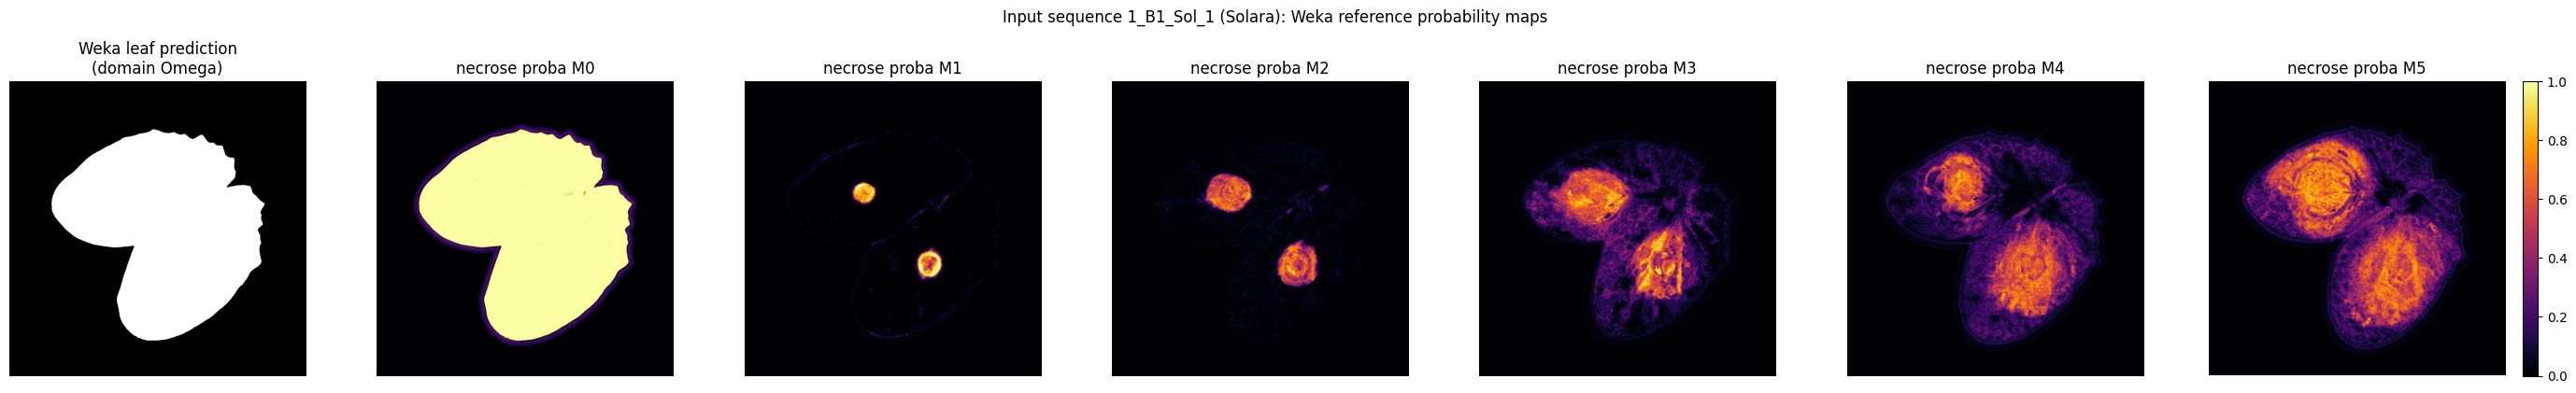

In [ ]:
import matplotlib.pyplot as plt
from skimage import io

fig, axes = plt.subplots(1, len(PROBA) + 1, figsize=(4 * (len(PROBA) + 1), 4))
leaf = io.imread(WEKA[0], as_gray=True)
axes[0].imshow(leaf, cmap="gray")
axes[0].set_title("Weka leaf prediction\n(domain Omega)")
for k_, ax in enumerate(axes[1:]):
    p = io.imread(PROBA[k_], as_gray=True)
    im_ = ax.imshow(p, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"necrose proba {os.path.basename(PROBA[k_]).split('_')[2]}")
fig.colorbar(im_, ax=axes[-1], fraction=0.046)
for ax in axes: ax.axis("off")
fig.suptitle("Input sequence 1_B1_Sol_1 (Solara): Weka reference probability maps", y=1.02)
plt.tight_layout()
plt.savefig("/content/preview_inputs.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Author functions — image readers and (D, a, K) initialization (verbatim port)

The cells below copy the author's functions **line-for-line** from
`readRegions.py` (`readheav`, `readregion`, `initDiffusion` — D initialization from
connected-component area growth over the sequence) and `readImages.py` (`readimage`,
`initaK` — logistic-inversion initialization of the growth rate a and capacity K via
`scipy.optimize.least_squares`). Only the module imports are adapted; the numerics are unchanged.
**日本語:** `readRegions.py` と `readImages.py` の関数を数式を変えずにコピーします
(D の初期化は連結成分面積の増加から、a・K の初期化はロジスティック逆算+最小二乗)。

In [ ]:
import numpy as np
from skimage import color, io
from skimage.transform import rescale
from skimage.measure import label, regionprops
from scipy.optimize import least_squares

def readheav(name):
    """readRegions.py: binary leaf image (Heaviside)."""
    img = io.imread(name, as_gray=True)
    img = img - np.mean(img)
    img = np.where(img < -1e-1, 0., 1.)
    return img

def readregion(name):
    """readRegions.py: binary lesion image at 0.5*max threshold (proba > 0.5)."""
    img = io.imread(name, as_gray=True)
    img = np.where(img < img.max() * .5, 0., 1.)
    return img

def readimage(name):
    """readImages.py: grayscale image."""
    img = io.imread(name, as_gray=True)
    return img

def _area_top2(im):
    l_ = label(im)
    regions = regionprops(l_)
    a_ = np.zeros(len(regions))
    for i_, p in enumerate(regions):
        a_[i_] = p.area
    return a_[np.argsort(a_)[-2:]]

def initDiffusion(PROBA, s, f):
    """readRegions.py initDiffusion (verbatim numerics): initial D from lesion area growth."""
    im = readheav(WEKA[s + 1])
    im = rescale(im, f, anti_aliasing=False, preserve_range=True)
    nx, ny = im.shape
    im0 = readregion(PROBA[s + 1]); im0 = rescale(im0, f, anti_aliasing=False, preserve_range=True)
    im1 = readregion(PROBA[s + 2]); im1 = rescale(im1, f, anti_aliasing=False, preserve_range=True)
    im2 = readregion(PROBA[s + 3]); im2 = rescale(im2, f, anti_aliasing=False, preserve_range=True)
    im3 = readregion(PROBA[s + 4]); im3 = rescale(im3, f, anti_aliasing=False, preserve_range=True)
    im4 = readregion(PROBA[s + 5]); im4 = rescale(im4, f, anti_aliasing=False, preserve_range=True)
    a0, a1, a2, a3, a4 = (_area_top2(x) for x in (im0, im1, im2, im3, im4))
    D01 = np.mean(np.abs(a1 - a0) / np.pi) / 16.
    D12 = np.mean(np.abs(a1 - a2) / np.pi) / 16.
    D23 = np.mean(np.abs(a2 - a3) / np.pi) / 16.
    D34 = np.mean(np.abs(a3 - a4) / np.pi) / 16.
    D02 = np.mean(np.abs(a2 - a0) / np.pi) / (16. * 2.)
    D13 = np.mean(np.abs(a3 - a1) / np.pi) / (16. * 2.)
    D24 = np.mean(np.abs(a4 - a2) / np.pi) / (16. * 2.)
    D03 = np.mean(np.abs(a3 - a0) / np.pi) / (16. * 3.)
    D13b = np.mean(np.abs(a4 - a1) / np.pi) / (16. * 3.)   # variable named D13 in the original
    D04 = np.mean(np.abs(a4 - a0) / np.pi) / (16. * 4.)
    D = np.mean([D01, D12, D23, D34, D02, D13, D24, D03, D13b, D04])
    print('D = ', D)
    return D, im, im0, im1, im2, im3, im4

### 7b. `initaK` — initial growth rate *a* and capacity *K*

Verbatim port of `readImages.py::initaK`: per-pixel logistic inversion of the probability jumps
between consecutive dates gives the initial a; K starts at the max observed probability and is
refined together with a by `least_squares` on two residual means. **日本語:** 観測確率の逐次差から
a・K の初期値を `least_squares` で推定します(原文のまま)。

In [ ]:
def initaK(PROBA, s, f, im0, N, dt):
    """readImages.py initaK (verbatim numerics)."""
    nx, ny = im0.shape
    img0 = readimage(PROBA[s + 1]); img0 = rescale(img0, f, anti_aliasing=False, preserve_range=True)
    img1 = readimage(PROBA[s + 2]); img1 = rescale(img1, f, anti_aliasing=False, preserve_range=True)
    img2 = readimage(PROBA[s + 3]); img2 = rescale(img2, f, anti_aliasing=False, preserve_range=True)
    uobs = np.zeros((N, nx * ny))
    uobs[int(1 / dt) - 1, :] = img1.reshape(nx * ny)
    uobs[int(2 / dt) - 1, :] = img2.reshape(nx * ny)
    img3 = readimage(PROBA[s + 4]); img3 = rescale(img3, f, anti_aliasing=False, preserve_range=True)
    img4 = readimage(PROBA[s + 5]); img4 = rescale(img4, f, anti_aliasing=False, preserve_range=True)

    def initlog(X):
        a_ = X[0]; K_ = X[1]
        return [np.mean(img2[np.where(img1 > 0)] - K_ / (1 + (K_ / img1[np.where(img1 > 0)] - 1) * np.exp(-a_))),
                np.mean(img4[np.where(img3 > 0)] - K_ / (1 + (K_ / img3[np.where(img3 > 0)] - 1) * np.exp(-a_)))]

    K = float(max(img1.max(), img2.max()))
    a12temp = np.zeros((nx, ny))
    for i_ in range(nx):
        for j_ in range(ny):
            if img1[i_, j_] > 0 and img2[i_, j_] > 0 and img1[i_, j_] < K and img2[i_, j_] < K:
                a12temp[i_, j_] = np.abs(-np.log((K / img2[i_, j_] - 1) / (K / img1[i_, j_] - 1)))
    a12 = float(a12temp.mean())
    a23temp = np.zeros((nx, ny))
    for i_ in range(nx):
        for j_ in range(ny):
            if img3[i_, j_] > 0 and img2[i_, j_] > 0 and img3[i_, j_] < K and img2[i_, j_] < K:
                a23temp[i_, j_] = np.abs(-np.log((K / img3[i_, j_] - 1) / (K / img2[i_, j_] - 1)))
    a23 = float(a23temp.mean())
    a34temp = np.zeros((nx, ny))
    for i_ in range(nx):
        for j_ in range(ny):
            if img3[i_, j_] > 0 and img4[i_, j_] > 0 and img3[i_, j_] < K and img4[i_, j_] < K:
                a34temp[i_, j_] = np.abs(-np.log((K / img4[i_, j_] - 1) / (K / img3[i_, j_] - 1)))
    a34 = float(a34temp.mean())
    a = np.mean([a12, a23, a34])
    res = least_squares(initlog, (a, K), bounds=((0, K - 0.001), (10, K + 0.001)))
    a, K = res.x
    print('a = ', a)
    print('K = ', K)
    return a, K, img0, img1, img2, img3, img4, uobs

## 8. Forward and backward solvers (verbatim numerics, PETSc → SciPy)

`steps.py::step1` integrates the forward Fisher–KPP equation: at every time step it solves the
implicit diffusion system `(I − dt·D·Δ) u* = u` (a fixed sparse matrix, factored once) with the
author's discrete Neumann condition on the leaf boundary, then applies the logistic growth
`u ← K / (1 + (K/u* − 1)·e^(−a·dt))` and masks outside the leaf. `steps.py::step2` integrates the
adjoint backward equation of S4 Appendix Eq. (B): `d = u + dt·(a·u·(1 − 2·b/K) − c)` with
`b = u(t)` and `c = u(t) − u_obs(t)`, then the same implicit diffusion. `forward_petsc.py::forward`
repeats the forward pass (growth applied before the diffusion solve, exactly as in the original)
with the optimal parameters. The only change: PETSc `Mat`/`KSP` → `scipy.sparse` + SuperLU.
**日本語:** 前進・随伴・最終前方ソルバーです。PETSc の疎行列ソルバーを SciPy(SuperLU)に置き
換えただけで、離散化・Neumann 境界・ロジスティック項・係数は原文のままです。

In [ ]:
import scipy.sparse as sp
from scipy.sparse.linalg import splu
from scipy.linalg import norm

def _system_factorized(nx, ny, D, dt):
    """steps.py matrix A = I - dt*D*Delta (5-point stencil), dx = dy = 1, factorized once."""
    n = nx * ny
    diagv = 1. + dt * (2.0 * D + 2.0 * D)
    offdx = -dt * 1.0 * D
    offdy = -dt * 1.0 * D
    I = np.arange(n); i = I // ny; j = I - i * ny
    rows = [I]; cols = [I]; vals = [np.full(n, diagv)]
    m = i > 0;    rows.append(I[m]); cols.append((I - ny)[m]); vals.append(np.full(int(m.sum()), offdx))
    m = i < nx - 1; rows.append(I[m]); cols.append((I + ny)[m]); vals.append(np.full(int(m.sum()), offdx))
    m = j > 0;    rows.append(I[m]); cols.append((I - 1)[m]);  vals.append(np.full(int(m.sum()), offdy))
    m = j < ny - 1; rows.append(I[m]); cols.append((I + 1)[m]); vals.append(np.full(int(m.sum()), offdy))
    A = sp.csr_matrix((np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))), shape=(n, n))
    return splu(A.tocsc())

def _apply_neumann(Uflat, im, boundary, vx, vy):
    """steps.py discrete Neumann condition on the leaf boundary (same rows/indices)."""
    nx, ny = im.shape
    U = Uflat.reshape(nx, ny)
    b0, b1 = boundary
    denom = np.maximum(vx[b0, b1] + vy[b0, b1], 1)
    U[b0, b1] = (U[b0 + 1, b1] * vx[b0, b1] + U[b0, b1 + 1] * vy[b0, b1]) / denom
    return U.reshape(-1)

def _domain(im):
    boundary = np.where(im[0:-1, 0:-1] - im[1:, 1:] != 0)
    vx = im[1:, :] - im[0:-1, :]
    vy = im[:, 1:] - im[:, 0:-1]
    return boundary, vx, vy

def step1(D, a, K, im0, im, T, dt):
    """steps.py step1: forward KPP (implicit diffusion then logistic growth)."""
    nx, ny = im.shape
    Nst = int(T / dt)
    usave = np.zeros((Nst, nx * ny))
    boundary, vx, vy = _domain(im)
    lu = _system_factorized(nx, ny, D, dt)
    ID = im.reshape(-1)
    U = im0.reshape(-1).astype(float).copy()
    usave[0, :] = U
    for n_ in range(1, Nst):
        Utemp = lu.solve(U)
        Utemp = _apply_neumann(Utemp, im, boundary, vx, vy)
        U = K / (1. + (K / Utemp - 1.) * np.exp(-a * dt))
        U = U * ID
        usave[n_, :] = U
    return usave

def step2(D, a, K, v, vobs, im, T, dt):
    """steps.py step2: backward adjoint problem (S4 Appendix Eq. B)."""
    nx, ny = im.shape
    Nst = int(T / dt)
    lsave = np.zeros((Nst, nx * ny))
    boundary, vx, vy = _domain(im)
    lu = _system_factorized(nx, ny, D, dt)
    ID = im.reshape(-1)
    U = np.zeros(nx * ny)
    lsave[0, :] = U
    for n_ in range(1, Nst):
        b = v[Nst - n_]
        c = v[Nst - n_] - vobs[Nst - n_]
        d = U + dt * (a * U * (1. - 2. * b / K) - c)
        Utemp = lu.solve(d)
        Utemp = _apply_neumann(Utemp, im, boundary, vx, vy)
        U = Utemp * ID
        lsave[n_, :] = U
    return lsave

def forward(D, a, K, im0, im, T, dt):
    """forward_petsc.py forward (growth before diffusion solve); VTK/tqdm outputs omitted."""
    nx, ny = im.shape
    Nst = int(T / dt)
    usave = np.zeros((Nst, nx * ny))
    boundary, vx, vy = _domain(im)
    lu = _system_factorized(nx, ny, D, dt)
    ID = im.reshape(-1)
    U = im0.reshape(-1).astype(float).copy()
    usave[0, :] = U
    for n_ in range(1, Nst):
        d = U + dt * a * U * (1. - U / K)
        Utemp = lu.solve(d)
        Utemp = _apply_neumann(Utemp, im, boundary, vx, vy)
        U = Utemp * ID
        usave[n_, :] = U
    return usave

print("Solvers defined (PETSc -> SciPy adaptation).")

Solvers defined (PETSc -> SciPy adaptation).


### 8b. Parameters (verbatim from `Parameters.py`)

Image scaling `f = 0.3`, horizon `T = 4` days with `dt = 0.01` (N = 400 steps), gradient step
sizes `rho1 = 1`, `rho2 = 1e-3`, tolerance `tol = 1e-2`, at most `Maxiter = 2` optimization
iterations — exactly the author's defaults. **日本語:** 著者の `Parameters.py` の既定値をそのまま
使います。

In [ ]:
# Parameters.py (verbatim)
f = 0.3          # image scaling
T = 4.           # final time (days)
dt = .01         # time step
N = int(T / dt)  # number of time steps
tol = 1e-2       # tolerance on the cost function / gradient
rho1 = 1.; rho2 = 1e-3   # gradient step sizes
Maxiter = 2      # maximum optimization iterations
print(dict(f=f, T=T, dt=dt, N=N, tol=tol, rho1=rho1, rho2=rho2, Maxiter=Maxiter))

{'f': 0.3, 'T': 4.0, 'dt': 0.01, 'N': 400, 'tol': 0.01, 'rho1': 1.0, 'rho2': 0.001, 'Maxiter': 2}


## 9. Initialize D, a, K on the sample sequence (author driver, `s = 0`)

Following `LoopOnFolders.py` exactly: `initDiffusion(PROBA, s*6, f)` initialises the diffusion
from the connected-component area growth, and `initaK(...)` initialises the growth rate and
capacity. With `s = 0`, the sequence uses `WEKA[1]` (leaf) and `PROBA[1..5]` = necrose maps
M1..M5 — i.e. the day-3 map as initial condition and the four later maps as observations, matching
the paper's protocol. **日本語:** 著者ドライバどおりに D・a・K を初期化します(初期条件は 3 日目
画像 M1、観測は M2〜M5)。

In [ ]:
import time

t0 = time.time()
s = 0  # single sequence (author indexing: 6 images per folder)
D, im, im0, im1, im2, im3, im4 = initDiffusion(PROBA, s * 6, f)
D = float(D)
a, K, img0, img1, img2, img3, img4, uobs = initaK(PROBA, s * 6, f, im0, N, dt)
a = float(a); K = float(K)
nx, ny = im0.shape
leafarea = np.sum(im)
print("grid:", (nx, ny), "nodes:", nx * ny, "| leaf area (scaled px):", leafarea)
print("arrays usave/uobs: %d x %d float64 = %.2f GB each" % (N, nx * ny, N * nx * ny * 8 / 2**30))
print("init time: %.1f s" % (time.time() - t0))

D =  17.914463815783837


a =  0.9294800825825327
K =  0.9712195267734453
grid: (307, 308) nodes: 94556 | leaf area (scaled px): 31387.530754262025
arrays usave/uobs: 400 x 94556 float64 = 0.28 GB each
init time: 0.8 s


## 10. Variational optimization loop (port of `LoopOnFolders.py`)

Each iteration: (1) forward solve `u = step1(D, a, K, im0, im, T, dt)`, (2) adjoint backward solve
`l = step2(D, a, K, u, uobs, im, T, dt)`, (3) gradient updates of D, a, K exactly as in the
author's driver (`D += rho1/(T·A)·Σ ∇u·∇l`, `a -= rho2/(T·A)·Σ u(1−u/K)·l`,
`K += rho2/(T·A)·Σ a·u²/K²`), where `A` is the scaled leaf area. The loop stops when the relative
data misfit `Jrel = ‖u−u_obs‖(T=1)+‖u−u_obs‖(T=2) / Σ u_obs` or the gradient `dJ` drops below
`tol`, or after `Maxiter = 2` iterations. **日本語:** 各反復で前進・随伴・勾配更新を行い、相対
コスト Jrel が許容値以下または 2 反復で停止します。

In [ ]:
dJ = 1.; miter = 0; Jrel = 1.
while Jrel > tol and dJ > tol and miter < Maxiter:
    t_ = time.time()
    u = step1(D, a, K, im0, im, T, dt)
    print('forward #%d done... (%.1f s)' % (miter, time.time() - t_)); t_ = time.time()
    l = step2(D, a, K, u, uobs, im, T, dt)
    print('backward #%d done... (%.1f s)' % (miter, time.time() - t_))

    Gu = np.gradient(u); Gl = np.gradient(l)
    Dnew = float(D + rho1 / (T * leafarea) * np.sum(Gu[0] * Gl[0] + Gu[1] * Gl[1]))
    anew = float(a - rho2 / (T * leafarea) * np.sum(u * (1 - u / K) * l))
    Knew = float(K + rho2 / (T * leafarea) * np.sum(a * u * u / K**2))
    print('gradient #%d done...' % miter)

    dJ = np.sqrt((1. / (T * leafarea) * np.sum(Gu[0] * Gl[0] + Gu[1] * Gl[1]))**2
                 + (1. / (T * leafarea) * np.sum(u * (1 - u / K) * l))**2)
    J = norm(u[int(1 / dt) - 1, :] - uobs[int(1 / dt) - 1, :]) \
        + norm(u[int(2 / dt) - 1, :] - uobs[int(2 / dt) - 1, :])
    Jrel = J / np.sum(uobs)
    D, a, K = Dnew, anew, Knew
    miter = miter + 1
    print('Relative error = ', Jrel, '| D =', D, '| a =', a, '| K =', K)

/tmp/ipykernel_704/1371160255.py:48: RuntimeWarning: divide by zero encountered in divide
  U = K / (1. + (K / Utemp - 1.) * np.exp(-a * dt))


forward #0 done... (15.2 s)


backward #0 done... (15.4 s)


gradient #0 done...


Relative error =  0.007832635055195956 | D = 17.90412337452877 | a = 0.9300404868007481 | K = 0.9718374993839523


## 11. Final forward solve and comparison with the paper's S6 Appendix

Following the author driver, we re-solve the forward problem with the optimized parameters and
compute the relative misfits `Jrel` (T = 1, 2), `J3rel` (T = 1..3) and `J4rel` (T = 1..4). We then
compare against **S6 Appendix, Table A, row 1 (Solara)**: D̂ = 4.51e-01, â = 4.84e-01,
J = 1.76e-02. The S6 table does not publish the stipule-to-row mapping, so row 1 (first Solara
individual) is used as the closest available reference; agreement is expected to be
order-of-magnitude / same-cultivar-plausible, not exact, because one row corresponds to one
unspecified stipule. Raw D is in scaled-pixel²/day; S6's D̂ is a relative diffusion (cm²/day, see
paper's *Parameters estimation* section) — we compare D up to the unpublished landmark
calibration. **日本語:** 最適パラメータで前方問題を解き直し、論文 S6 付録 表 A 第 1 行
(Solara: D̂=0.451, â=0.484, J=1.76e-02) と比較します。行と個体の対応は非公開のため、厳密一致
ではなくオーダー・妥当性の比較です。

In [ ]:
t_ = time.time()
uopt = forward(D, a, K, im0, im, T, dt)
print('final forward done... (%.1f s)' % (time.time() - t_))

uobs = np.zeros((N, nx * ny))
uobs[int(1 / dt) - 1, :] = img1.reshape(nx * ny)
uobs[int(2 / dt) - 1, :] = img2.reshape(nx * ny)
J = norm(uopt[int(1 / dt) - 1, :] - uobs[int(1 / dt) - 1, :]) \
    + norm(uopt[int(2 / dt) - 1, :] - uobs[int(2 / dt) - 1, :])
Jrel = J / np.sum(uobs)
uobs[int(3 / dt) - 1, :] = img3.reshape(nx * ny)
J3 = norm(uopt[int(1 / dt) - 1, :] - uobs[int(1 / dt) - 1, :]) \
     + norm(uopt[int(2 / dt) - 1, :] - uobs[int(2 / dt) - 1, :]) \
     + norm(uopt[int(3 / dt) - 1, :] - uobs[int(3 / dt) - 1, :])
J3rel = J3 / np.sum(uobs)
uobs[int(4 / dt) - 1, :] = img4.reshape(nx * ny)
J4 = norm(uopt[int(1 / dt) - 1, :] - uobs[int(1 / dt) - 1, :]) \
     + norm(uopt[int(2 / dt) - 1, :] - uobs[int(2 / dt) - 1, :]) \
     + norm(uopt[int(3 / dt) - 1, :] - uobs[int(3 / dt) - 1, :]) \
     + norm(uopt[int(4 / dt) - 1, :] - uobs[int(4 / dt) - 1, :])
J4rel = J4 / np.sum(uobs)
print('Jrel  =', Jrel)
print('J3rel =', J3rel)
print('J4rel =', J4rel)
print('D = ', D)
print('a = ', a)
print('K = ', K)

final forward done... (14.7 s)
Jrel  = 0.00784224454081209
J3rel = 0.0071374676881392285
J4rel = 0.006639418784938598
D =  17.90412337452877
a =  0.9300404868007481
K =  0.9718374993839523


### 11b. Comparison table (this run vs S6 Appendix row 1)

**日本語:** 本実行の推定値と論文 S6 付録の値を表にします。

In [ ]:
s6_row1 = {"D (S6 row1, Solara)": 4.51e-01, "a (S6 row1, Solara)": 4.84e-01,
           "J (S6 row1)": 1.76e-02}
import pandas as pd
comparison = pd.DataFrame({
    "quantity": ["diffusion D (raw, scaled-px^2/day)", "growth rate a (1/day)", "relative cost Jrel"],
    "this notebook": [D, a, Jrel],
    "paper S6 row1 (Solara)": [s6_row1["D (S6 row1, Solara)"], s6_row1["a (S6 row1, Solara)"],
                               s6_row1["J (S6 row1)"]],
})
comparison["ratio (ours / S6)"] = comparison["this notebook"] / comparison["paper S6 row1 (Solara)"]
comparison.style.format({"this notebook": "{:.4g}", "paper S6 row1 (Solara)": "{:.4g}",
                         "ratio (ours / S6)": "{:.3g}"})
display(comparison)

,quantity,this notebook,paper S6 row1 (Solara),ratio (ours / S6)
0,"diffusion D (raw, scaled-px^2/day)",17.904123,0.4510,39.698721
1,growth rate a (1/day),0.930040,0.4840,1.921571
2,relative cost Jrel,0.007842,0.0176,0.445582


## 12. Observations vs fitted model

Top row: the Weka symptomatic-probability observations (reference annotations) at T = 1..4 days
after the initial condition; bottom row: the fitted Fisher–KPP solution at the same times
(this notebook's output). **日本語:** 上段が観測(Weka 参照アノテーション)、下段が当てはめた
Fisher–KPP 解です。

/tmp/ipykernel_704/4130253759.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


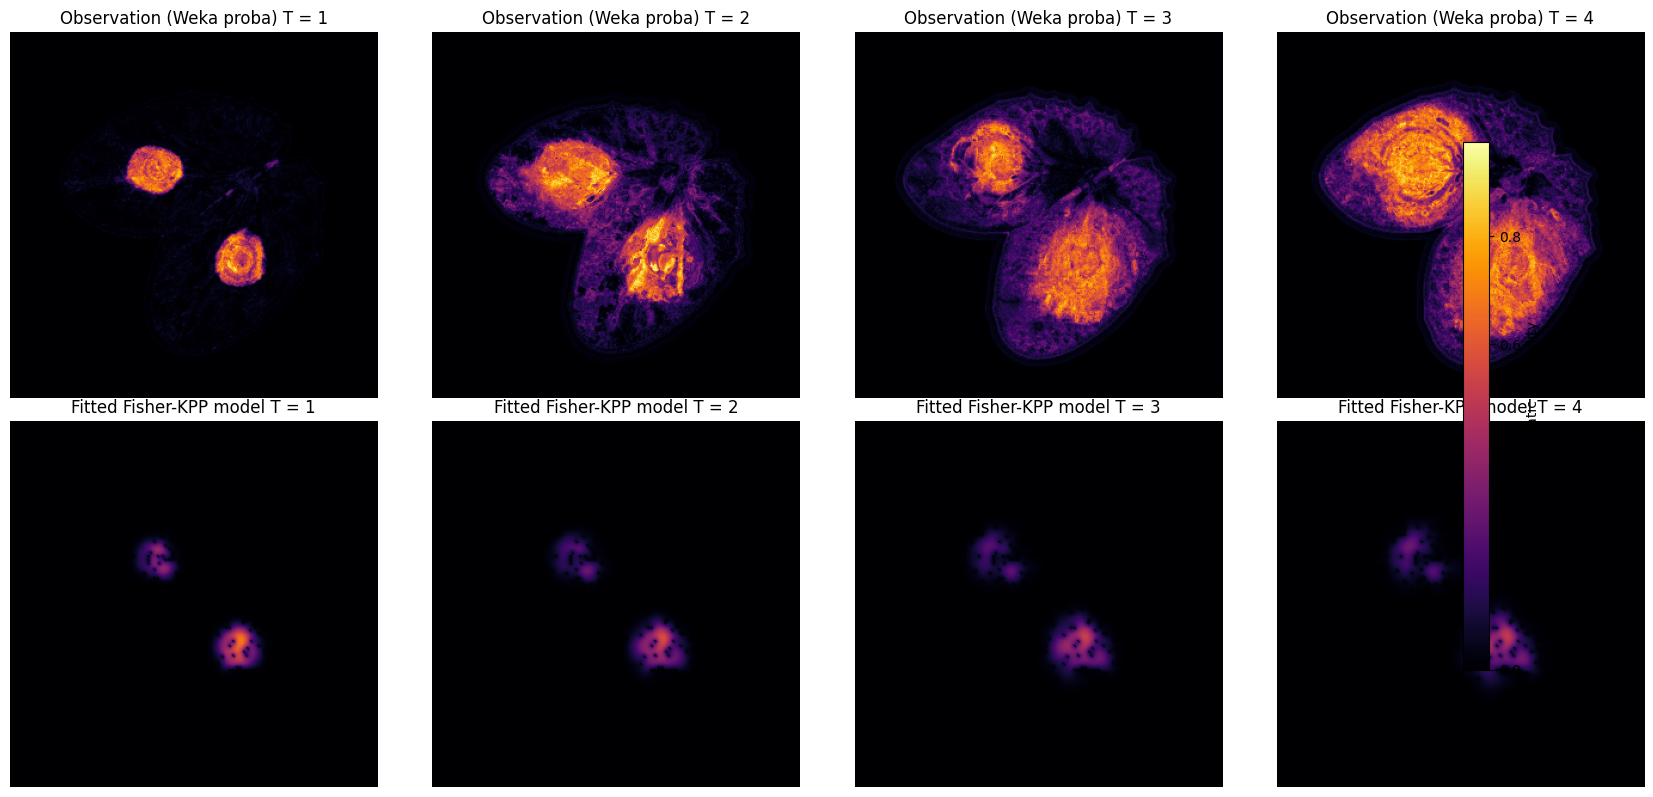

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
vmax = max(img1.max(), img2.max(), img3.max(), img4.max())
for k_ in range(4):
    obs = (img1, img2, img3, img4)[k_]
    mod = uopt[int((k_ + 1) / dt) - 1, :].reshape(nx, ny)
    imo = axes[0, k_].imshow(obs, cmap="inferno", vmin=0, vmax=vmax)
    axes[0, k_].set_title("Observation (Weka proba) T = %d" % (k_ + 1))
    axes[1, k_].imshow(mod, cmap="inferno", vmin=0, vmax=vmax)
    axes[1, k_].set_title("Fitted Fisher-KPP model T = %d" % (k_ + 1))
fig.colorbar(imo, ax=axes, fraction=0.02, label="symptomatic probability")
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout()
plt.savefig("/content/model_vs_obs.png", dpi=110, bbox_inches="tight")
plt.show()

## 13. Export the estimated parameters

Small CSV export of this single-stipule estimate (kept inside the Colab VM).
**日本語:** 推定結果を CSV として保存します。

In [ ]:
results = pd.DataFrame([{
    "sequence": "1_B1_Sol_1", "cultivar": "Solara",
    "D_raw_scaled_px2_per_day": D, "a_per_day": a, "K": K,
    "Jrel_T1_T2": Jrel, "J3rel_T1_T3": J3rel, "J4rel_T1_T4": J4rel,
    "grid_nx": nx, "grid_ny": ny, "leafarea_scaled_px": leafarea,
}])
display(results.T)
results.to_csv("/content/lesionkpp_estimates_1_B1_Sol_1.csv", index=False)
print("saved /content/lesionkpp_estimates_1_B1_Sol_1.csv")

,0
sequence,1_B1_Sol_1
cultivar,Solara
D_raw_scaled_px2_per_day,17.904123
a_per_day,0.93004
K,0.971837
Jrel_T1_T2,0.007842
J3rel_T1_T3,0.007137
J4rel_T1_T4,0.006639
grid_nx,307
grid_ny,308


saved /content/lesionkpp_estimates_1_B1_Sol_1.csv


## 14. Interpretation, differences from the paper, and validation record

**What was reproduced.** The paper's parameter-estimation pipeline (Materials and methods,
*Spatial lesion growth model* + *Parameters estimation from image sequences*, and S4 Appendix):
Weka probability maps as observations, day-3 image as initial condition, forward–adjoint
variational assimilation of the Fisher–KPP equation on the leaf domain with homogeneous Neumann
conditions, gradient descent on (D, a, K) — executed on the authors' own example sequence
`1_B1_Sol_1` with the author's default parameters.

**Adaptations (all documented above).**
1. PETSc `Mat`/`KSP` → `scipy.sparse` + SuperLU (identical linear systems; the factorization is
   reused within a pass, which the author's repeated `ksp.solve` on a fixed operator also allows).
2. VTK/pyevtk outputs and tqdm progress bars replaced by in-notebook PNG figures.
3. The original driver's missing `plt` import and in-loop `forward_petsc` import are avoided by
   calling the ported functions directly; the numerics are unchanged.

**Differences / caveats.**
- S6 row 1 ↔ `1_B1_Sol_1` identity is not published; the comparison is plausibility-level.
- Raw D is in scaled-pixel²/day; the paper's relative D̂ (cm²/day) needs the landmark-based leaf
  calibration that is not part of the repository (S6 gives leaf surfaces in cm² only).
- One stipule ≠ the 32-stipule analysis: no ANOVA, no cultivar comparison, no classifier
  retraining, no Coherent-Point-Drift registration (the shipped images are pre-registered).

**References.** Leclerc et al. (2023) PLoS Comput Biol e1011627 and its S4/S6 Appendices;
LesionKPP code, commit `fa1cb6f4d2de71c6e19eba34d3a23e7854f8ba1e`, GPL-3.0; example images from
the same repository; datasets doi:10.57745/MQXKCP (image sequences) and doi:10.57745/5B1XGU
(segmentation classifiers/predictions) were inspected but not needed for this minimal example.
**日本語:** 本ノートブックは論文のパラメータ推定パイプラインを著者同梱の 1 例で再現したもので
あり、全個体解析・ANOVA・単位換算(cm²/day)は未実施です。